---
# ***Asignatura: Ciencia de Datos***
---

## **Unidad 1**: Pandas Avanzado - DataFrames

### ***Universidad Nacional de Chilecito***

---


Representa una estructura de datos **tabular** que contiene una colección de columnas, cada una de las cuales tiene un tipo de datos determinado (number, string, boolean, etc.).

Podemos pensar un objeto `DataFrame` como un diccionario de `Series` "alineadas" (que comparten el mismo índice).

Una instancia de DataFrame tiene **índices de columnas y de filas**.  




### `DataFrame` como un diccionario de `Series` "alineadas"

Un `DataFrame` es un tipo de datos análogo a `Series` en dos dimensiones.

Como ejemplo, generemos un DataFrame con datos de área y población para distintos estados combinando dos series.

1) Generemos un objeto `Series` con el área de algunos estados a partir de un diccionario:

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
area_dict = {'California': 423967, 'Texas': 695662, 'New York': 141297,
             'Florida': 170312, 'Illinois': 149995}
area = pd.Series(area_dict)
area

,0
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


2) Generemos un objeto `Series` con la población de algunos estados a partir de listas:

In [ ]:
states_list = ['Illinois','Texas','New York', 'Florida', 'California']
states_pop = [12882135, 26448193, 19651127, 19552860, 38332521]
population = pd.Series(states_pop, index= states_list)
population

,0
Illinois,12882135
Texas,26448193
New York,19651127
Florida,19552860
California,38332521


Generamos un objeto `DataFrame` a partir de los dos objetos `Series` generados en los puntos anteriores:

In [ ]:
states = pd.DataFrame({'population': population,
                       'area': area})
states

,population,area
California,38332521,423967
Florida,19552860,170312
Illinois,12882135,149995
New York,19651127,141297
Texas,26448193,695662


Al igual que Series, un DataFrame posee un atributo index:

In [ ]:
states.index

Index(['California', 'Florida', 'Illinois', 'New York', 'Texas'], dtype='object')

Además, tiene un atributo columns, que es un objeto de tipo Index conteniendo las etiquetas de columnas:

In [ ]:
states.columns

Index(['population', 'area'], dtype='object')

Pueden observar que tanto los nombres de filas como los nombres de columnas son objetos del tipo `Index`.

### DataFrame como un diccionario especializado

De forma similar, podemos pensar auna instancia de `DataFrame` como un diccionario:
    
* Un diccionario mapea una key con un valor
* Un `DataFrame` mapea un nombre de columna con una `Series` de datos.
    
Por ejemplo, pedir el atributo `area` del `DataFrame` `states` devuelve una instancia de `Series`.


In [ ]:
states['area']

,area
California,423967
Florida,170312
Illinois,149995
New York,141297
Texas,695662


In [ ]:
states.area

,area
California,423967
Florida,170312
Illinois,149995
New York,141297
Texas,695662


In [ ]:
print(type(states['area']))
print(type(states.area))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
states['area'] is states.area

True

In [ ]:
states['area'] == states.area

,area
California,True
Florida,True
Illinois,True
New York,True
Texas,True


¿Qué diferencia hay entre == y is ?


<a id="section_constructor"></a>
## Constructor

#### Documentación
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html


<a id="section_constructor_from_series"></a>
### Desde una instancia de `Series`:

In [ ]:
pd.DataFrame(population, columns=['population'])

,population
Illinois,12882135
Texas,26448193
New York,19651127
Florida,19552860
California,38332521


<a id="section_constructor_from_dicts"></a>
### Desde una lista de `dicts`

In [ ]:
dict_0 = {'a': 0, 'b': 0}
dict_1 = {'a': 1, 'b': 2}
dict_2 = {'a': 2, 'b': 4}

data = [dict_0, dict_1, dict_2]

pd.DataFrame(data)

,a,b
0,0,0
1,1,2
2,2,4


Otra forma de construir lo mismo, usando listas por comprensión:

In [ ]:
data = [{'a': i, 'b': 2 * i}
        for i in range(3)]

print(data)

pd.DataFrame(data)

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}]


,a,b
0,0,0
1,1,2
2,2,4


Incluso si alguna key no tiene un valor asociado en el diccionario, Pandas completa con NaN el valor:

In [ ]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


<a id="section_constructor_from_2darray"></a>
### Desde un array `Numpy` de dos dimensiones:



In [ ]:
array_2d = np.random.rand(3, 2)
# veamos qué hay en la variable array_2d:
print(array_2d)

columns_names = ['foo', 'bar']
rows_names = ['a', 'b', 'c']

pd.DataFrame(array_2d, columns=columns_names, index=rows_names)


[[0.71609621 0.97161848]
 [0.76954787 0.6980396 ]
 [0.24866948 0.97000195]]


,foo,bar
a,0.716096,0.971618
b,0.769548,0.698040
c,0.248669,0.970002


<a id="section_selection"></a>
## Selección de datos en `DataFrame`

Vamos a ver ahora distintas formas de seleccionar elementos en instancias de `DataFrame`

Comencemos creando el objeto `data`:

In [ ]:
area = pd.Series({'California': 423967, 'Texas': 695662,
                  'New York': 141297, 'Florida': 170312,
                  'Illinois': 149995})
pop = pd.Series({'California': 38332521, 'Texas': 26448193,
                 'New York': 19651127, 'Florida': 19552860,
                 'Illinois': 12882135})
data = pd.DataFrame({'area':area, 'pop':pop})
data

,area,pop
California,423967,38332521
Texas,695662,26448193
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


<a id="section_selection_head_tail"></a>
### Primeros n elementos, últimos n elementos

Puede accederse a los primeros n elementos del DataFrame con el método df.head(n). Del mismo modo, puede aplicarse el método df.tail(n) para acceder a los últimos elementos del DataFrame:

In [ ]:
data.head(2)

,area,pop
California,423967,38332521
Texas,695662,26448193


In [ ]:
data.tail(3)

,area,pop
New York,141297,19651127
Florida,170312,19552860
Illinois,149995,12882135


<a id="section_selection_sample"></a>
### Muestra aleatoria de n elementos

Con el método df.sample(n) obtenemos una muestra aleatória de n elementos:

In [ ]:
data.sample(2)

,area,pop
New York,141297,19651127
Illinois,149995,12882135


<a id="section_selection_col"></a>
### Columnas
    
Podemos acceder a las Series individuales que forman las columnas del DataFrame de forma análoga a un diccionario de varias formas:

* Vía el nombre de la columna:

In [ ]:
data['area']

,area
California,423967
Texas,695662
New York,141297
Florida,170312
Illinois,149995


* Como atributo:

In [ ]:
data.area

Ambas formas son equivalentes:

In [ ]:
data['area'] is data.area

`values` devuelve los valores de todos los elementos que conforman el objeto `DataFrame` como un objeto `numpy.ndarray`:

In [ ]:
data.values

<a id="section_selection_index"></a>
### Indexación
    
Vamos a indexar un objeto `DataFrame` con dos índices, uno para las filas y el otro para las columnas.
    
Las formas de indexar que vimos en arrays y es series sirven también para dataframes.

Recordemos cuáles son:
    

####  loc iloc

In [ ]:
data.iloc[:3, :2]

In [ ]:
data.loc[:'Illinois', :'pop']

####  Boolean masking

In [ ]:
data.loc[data.area > 423000, :]

,area,pop
California,423967,38332521
Texas,695662,26448193


####  Fancy indexing

In [ ]:
data.loc[:, ['pop', 'area']]

,pop,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


####  Combinando boolean masking y fancy indexing

In [ ]:
data.loc[data.area > 423000, ['pop', 'area']]

,pop,area
California,38332521,423967
Texas,26448193,695662


#### Algunas convenciones adicionales para indexar

Hasta ahora vimos cómo indexar un objeto `DataFrame` con un índice sobre filas y otro sobre columnas.

Podemos tambien indexarlos usando sólo un índice que se interpreta según el detalle que vemos a continuación.


En general, "fancy indexing" refiere a columnas, mientras que "slicing" refiere a filas:

In [ ]:
data[['area', 'area']]

,area,area
California,423967,423967
Texas,695662,695662
New York,141297,141297
Florida,170312,170312
Illinois,149995,149995


In [ ]:
data['Florida':'Illinois']

,area,pop
Florida,170312,19552860
Illinois,149995,12882135


Slicing puede referir filas por posición, en lugar de índices:

In [ ]:
data[1:3]

,area,pop
Texas,695662,26448193
New York,141297,19651127


Boolean masking se interpretada por defecto sobre filas:

In [ ]:
data[data.area > 423000]

,area,pop
California,423967,38332521
Texas,695662,26448193


<a id="section_modify"></a>
### Moficación de valores

Podemos crear una nueva columna en un objeto DataFrame como el resultado de una operación sobre otros elementos del objeto:

In [ ]:
data['density'] = data['pop'] / data['area']
data

,area,pop,density
California,423967,38332521,90.413926
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


Cualquiera de las formas de indexar que vimos puede ser usada para asignar o modificar valores:

In [ ]:
data.iloc[0, 2] = 90
data

,area,pop,density
California,423967,38332521,90.000000
Texas,695662,26448193,38.018740
New York,141297,19651127,139.076746
Florida,170312,19552860,114.806121
Illinois,149995,12882135,85.883763


# Google Drive
---
Con ayuda del siguiente código podrás vincular tu cuenta de Google Drive.

Como recomendación te pedimos que crees una carpeta denominada como `CCDAA` dentro de tu carpeta principal de Drive.

Dentro de esa carpeta crea otra carpeta denominada `Data` en esa carpeta deberás subir siempre los archivos que necesites utilizar.

Con el siguiente comando podrás abrir el archivo que vamos a necesitar en ésta ocasión:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
pathCurso = '/content/drive/MyDrive/CienciaDatos/DataSet/winemag-data-130k-v2.csv'

Mounted at /content/drive


# Exploración del dataset

En esta clase, vamos a trabajar con un dataset de review de vinos: `winemag-data-130k-v2.csv`.


* El dataset deberá estar dentro de la carpeta `DataSet`
* Lo podemos descargar en: https://www.kaggle.com/zynicide/wine-reviews/ (nos tenemos que registrar)

## Antes que nada, hablemos de Tipos de Variables

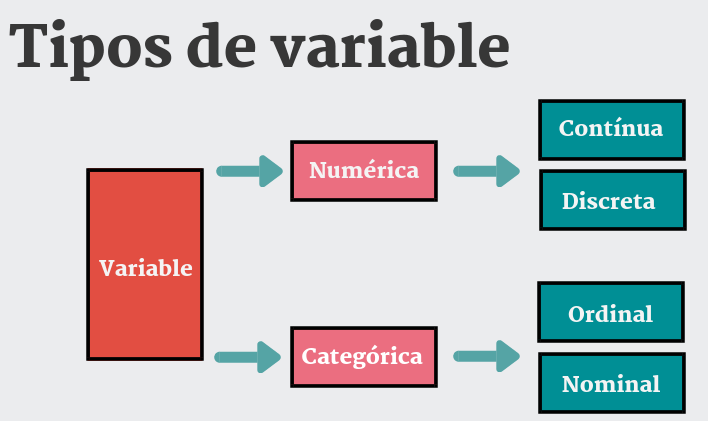

In [ ]:
import pandas as pd

wine_reviews_df = pd.read_csv(pathCurso)
wine_reviews_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


Vemos que la columna `Unnamed: 0`, es una columna con valores secuenciales, que por el momento podríamos quitar:

In [ ]:
del wine_reviews_df['Unnamed: 0']

In [ ]:
wine_reviews_df.head(2)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos


In [ ]:
# Funcion analisis descriptivo basico base de datos:
def descriptivo(datos):
    print("Head")
    display(datos.head())
    print("-----------------------------------------------------------------")
    print("")

    print("Nombre columnas")
    display(datos.columns)
    print("-----------------------------------------------------------------")
    print("")

    print("Shape")
    display(datos.shape)
    print("-----------------------------------------------------------------")
    print("")

    print("Information")
    display(datos.info())
    print("-----------------------------------------------------------------")
    print("")

    print("Describe")
    display(datos.describe())
    print("-----------------------------------------------------------------")
    print("")

    print("Datos ausentes")
    display(datos.isna().sum())
    print("-----------------------------------------------------------------")
    print("")


Exploremos un poco el dataset.

Imprimimos las primeras 5 filas:

In [ ]:
descriptivo(wine_reviews_df)

Head


,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


-----------------------------------------------------------------

Nombre columnas


Index(['country', 'description', 'designation', 'points', 'price', 'province',
       'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title',
       'variety', 'winery'],
      dtype='object')

-----------------------------------------------------------------

Shape


...

-----------------------------------------------------------------

Describe


,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


-----------------------------------------------------------------

Datos ausentes


,0
country,63
description,0
designation,37465
points,0
price,8996
province,63
region_1,21247
region_2,79460
taster_name,26244
taster_twitter_handle,31213


-----------------------------------------------------------------



In [ ]:
wine_reviews_df.head(5)

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [ ]:
display(wine_reviews_df.head(5))

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


Busco cual es el que tiene el valor maximo en puntos.

In [ ]:
# dir(wine_reviews_df)

In [ ]:
max_point = wine_reviews_df["points"].max()
print(max_point)
print(wine_reviews_df["points"].idxmax())

In [ ]:
# display(wine_reviews_df.iloc[345])
display(wine_reviews_df.iloc[wine_reviews_df["points"].idxmax()])

In [ ]:
# Podemos mesclar ambas formas de filtrar los datos en .loc
display(wine_reviews_df.loc[wine_reviews_df["points"].idxmax(),"description"])

Busco cual es el que tiene el valor mínimo en puntos.

In [ ]:
display(wine_reviews_df.iloc[wine_reviews_df["points"].idxmin()])

Cuantos maximos hay

In [ ]:
# wine_reviews_df['points'] == max_point

In [ ]:
maximos = wine_reviews_df[wine_reviews_df['points'] == max_point]
print(len(maximos))
maximos[["country","designation","price"]]

¿ Cuántas filas tiene el dataset? ¿ Y cuántas columnas ?

Esta pregunta, podemos responderla utilizando `shape`



In [ ]:
wine_reviews_df.shape

¿ Cuántos valores faltantes tiene el dataset en cada columna ?

In [ ]:
display(wine_reviews_df.isna().sum())

In [ ]:
# wine_reviews_df.shape[0]

In [ ]:
# En porcentaje de la cantidad de datos
display((wine_reviews_df.isna().sum()/wine_reviews_df.shape[0])*100)

Ahora, ¿Qué hacemos con los faltantes?

Pandas tiene el método .fillna() para imputar valores faltantes y el método .dropna() para eliminar filas con valores faltantes.

Veamos un poco de documentación:

In [ ]:
help(pd.DataFrame.dropna)

In [ ]:
help(pd.DataFrame.fillna)

Ahora, para no modificar nuestro dataset original, lo vamos a clonar con `copy()`

In [ ]:
# Clono ahora si modifico df no se modifica el original
df = wine_reviews_df.copy(deep=True)

Ahora vamos a trabajar sobre df.

In [ ]:
df.isna().sum()

In [ ]:
df.info()

Vemos que las columnas que tienen datos faltantes son designation, price, region_1, region_2, entre otras.

Por ahora, como solo estamos aprendiendo Pandas, no vamos a explorar mucho los datos para tomar decisiones. Simplemente vamos a aprender como se usa pandas. En próximas clases vamos a empezar a explorar los datos con mas detalle para tomar buenas decisiones.

Empecemos con el método fillna:

Vamos a imputar los valores faltantes de la columna "price" con la media de la columna.

In [ ]:
mean_price = df['price'].mean()
df['price'] = df['price'].fillna(mean_price)
print(mean_price)

Verificamos que no haya más nulos

In [ ]:
df.isna().sum()

Vemos que ahora hay 0 null values en la columna price

Ahora, completemos las columnas "designation", "region_1" y "region_2" con el valor por defecto: "dato faltante".

Podemos hacerlo pasandole un diccionario como parametro:

In [ ]:
default_value = "dato faltante"
df = df.fillna(value={'designation': default_value, "region_1": default_value, "region_2": default_value})

Rellenamos con dato faltante la variable designation, region 1 y region 2

In [ ]:
df.isna().sum()

Ahora nos queda la columna country y las demás. En este caso, lo que vamos a hacer es descartar las filas que tengan valores faltantes en esta columna.
Para esto, vamos a usar el método dropna() y vamos a pasarle el parámetro axis=0

Veamos cuantas filas tiene el dataset antes de borrar nulos:

In [ ]:
df.shape[0]

Borramos nulos:

In [ ]:
df = df.dropna(axis=0)

Y ahora debería haber varias filas menos:

In [ ]:
wine_reviews_df.shape[0]

In [ ]:
df.shape[0]

In [ ]:
wine_reviews_df.shape[0]-df.shape[0]

## Filtro por máscara

Vimos que en numpy podemos utilizar filtros. En pandas también podemos hacerlo y es algo que vamos utilizar mucho asique es importante aprender a usarlo bien!

Los filtros se utilizan igual que en numpy.

Seleccionemos todas las filas en las que country sea = 'US'

In [ ]:
# df['country'] == 'US'

In [ ]:
mask_country = df['country'] == 'US'
print(mask_country)

In [ ]:
print(df[mask_country].shape)
df[mask_country].head(5)

## Funciones de Dataframes

- value_counts
- unique
- nunique
- max
- min
- sort_values

Responder las siguientes preguntas utilizando lo que sabemos de pandas + lo que investigamos de las funciones de arriba (con la menor cantidad de funciones posibles):

a) ¿ Qúe valores distintos (únicos) hay en la columna country ?

b) ¿ Cuántos valores distintos hay en la columna country ?

c) ¿ Con qué frecuencia (cuantas veces) aparece cada uno de los paises ?

d) ¿ Cuál es el valor máximo de la columna price ?

e) ¿ Cuál es el valor mínimo de la columna price ?

f) ¿ Cuál es el vino más caro ?

g) ¿ Cuántos vinos tienen un precio por encima de la media ?


a) ¿ Qúe valores distintos (únicos) hay en la columna country ?

In [ ]:
print(df['country'].unique())

b) ¿ Cuántos valores distintos hay en la columna country ?

In [ ]:
print(len(df['country'].unique()))
print(df['country'].nunique())

c) ¿ Con qué frecuencia (cuantas veces) aparece cada uno de los paises ?

In [ ]:
print(df['country'].value_counts())

In [ ]:
print(df['country'].value_counts("%")*100)

d) ¿ Cuál es el valor máximo de la columna price ?

In [ ]:
df["price"].max()

e) ¿ Cuál es el valor mínimo de la columna price ?

In [ ]:
df["price"].min()

f) ¿ Cuál es el vino más caro ?

In [ ]:
# Cuantos maximos hay
# caro = df[df["price"]==df["price"].max()]
# display(caro)
# o
df[df["price"]==df["price"].max()]

g) ¿ Cuántos vinos tienen un precio por encima de la media ?

In [ ]:
# df["price"]>mean_price

In [ ]:
mask_avg_price = df["price"]>mean_price
mayormedia = df[mask_avg_price]
print(len(mayormedia))
print(mayormedia.shape[0])
display(mayormedia.head())

**Ejercicio** cuales son los vinos mas baratos?

In [ ]:
# Codigo
print(df[df["price"]==df["price"].min()].shape[0])
df[df["price"]==df["price"].min()]

**Haz doble click para ver la respuesta**

<!--
df[df["price"]==df["price"].min()]
 -->

# Group by


La función group by de pandas, nos permite agrupar dataframes a partir de una o más columnas y mediante funciones de agregación obtener insights de cada grupo.

Veamos ejemplos:

In [ ]:
group_by_country = df.groupby('country')
display(group_by_country)

Vemos que groupby nos devuelve un objeto pandas.core.groupby.generic.DataFrameGroupBy.

Sobre este objeto, podemos aplicar directamente funciones de agregación como .count(), .sum(), .mean(), etcétera:

In [ ]:
group_by_country.count().head()

In [ ]:
group_by_country.mean().head()

¿ Por qué cuando aplicamos la función mean solo nos trae 3 columnas y el indice ?

También podemos agrupar por múltiples columnas:

In [ ]:
group_by_country_prov = df.groupby(['country', 'province'])
group_by_country_prov.mean().head()

Y si no queremos que las variables por las que agrupamos se conviertan en indices y sean una columna más, podemos especificarlo en la función:

In [ ]:
group_by_country_prov = df.groupby(['country', 'province'], as_index=False)
group_by_country_prov.mean().head()

Finalmente, también podemos aplicar distintas funciones de agregación a cada columna.


1. Agrupar el dataset por pais.

2. Obtener una columna que tenga el precio medio por país y otra que contenga la sumatoria de puntos. (.mean() y .sum() ).

In [ ]:
group_by_country_prov = df.groupby(['country'], as_index=False).agg({'price': ['mean'],'points': ['count']})

group_by_country_prov.columns = ["Country",'Price mean', 'Points count']
display(group_by_country_prov.head())

# Sort values

Para ordenar un dataframe de pandas, podemos utilizar la función sort_values()


Ordenar el dataset por "points" de manera descendente.

In [ ]:
print("Tabla Ascendente por Points")
display(group_by_country_prov.sort_values(by=['Points count'], ascending=[True]).head())
print("")
print("--------------------------------")
print("")
print("Tabla Descendente por Points")
display(group_by_country_prov.sort_values(by=['Points count'], ascending=[False]).head())

# Manejo de Fechas

Vamos a trabajar con el dataset `certificados-personas-por-fecha-ingreso-provincia-localidad.csv` que se puede descargar desde este [link](https://www.datos.gob.ar/dataset/turismo-certificado-unico-habilitante-para-circulacion-cuhc---verano/archivo/turismo_176dc4bc-7597-4e9b-850d-0d27bcbca8d0) .

Leer el dataset con pandas: Tener en cuenta que hay una columna "fecha_ingreso". ¿ Cómo podemos especificarle a pandas que lea esa columna como una fecha ?  

- ¿ Cómo podemos acceder a el día/mes/año de una columna ?
- ¿ Cómo podemos acceder a la semana de el año de una fecha ?
- ¿ Cómo podemos acceder al día de la semana de una fecha ?

Podemos ver en la documentación de pandas, que esta lleno de atributos y funciones de las fechas que podemos utilizar. Por ejemplo, si queremos saber si una fecha corresponde a el primer día del mes: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.is_month_start.html


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
pathCurso = '/content/drive/MyDrive/CienciaDatos/DataSet/'

Con el siguiente comando podrás abrir el archivo que vamos a necesitar en ésta ocasión:

In [ ]:
# Importar pandas
import pandas as pd

ruta_archivo = pathCurso + 'certificados-personas-por-fecha-ingreso-provincia-localidad.csv'

In [ ]:
datos = pd.read_csv(ruta_archivo)
datos.head(5)

In [ ]:
datos.info()

In [ ]:
?pd.read_csv

In [ ]:
pd.to_datetime('2023-06-29')

In [ ]:
pd.to_datetime('23-06-29')

In [ ]:
pd.to_datetime('9-6-2023')

In [ ]:
?pd.to_datetime

In [ ]:
pd.to_datetime('9-6-2023',format='%d-%m-%Y')

In [ ]:
datos['fecha_ingreso_2']=pd.to_datetime(datos['fecha_ingreso'])

In [ ]:
datos.info()

In [ ]:
datos.head()

In [ ]:
def funcion(x):
  return pd.to_datetime(x, format='%Y-%m-%d')

In [ ]:
datos2 = pd.read_csv(ruta_archivo,date_parser=funcion)#lambda x: pd.to_datetime(x)
datos2

In [ ]:
datos2.info()

In [ ]:
?pd.read_csv

In [ ]:
datos2 = pd.read_csv(ruta_archivo,parse_dates=['fecha_ingreso'],date_parser=lambda x: pd.to_datetime(x))#lambda x: pd.to_datetime(x)
datos2

In [ ]:
datos2.info()

In [ ]:
datos2 = pd.read_csv(ruta_archivo,date_parser=lambda x: pd.to_datetime(x), index_col="fecha_ingreso")
datos2

In [ ]:
datos2.index

In [ ]:
datos3 = pd.read_csv(ruta_archivo)
datos3['fecha_ingreso'] = pd.to_datetime(datos3['fecha_ingreso'],format='%Y-%m-%d')


# datos3['year'] = pd.DatetimeIndex(datos3['fecha_ingreso']).year
# Otra forma
datos3['year'] = datos3['fecha_ingreso'].dt.year
datos3['month'] = datos3['fecha_ingreso'].dt.month
datos3['day'] = datos3['fecha_ingreso'].dt.day
# datos3['day'] = pd.DatetimeIndex(datos3['fecha_ingreso']).day

In [ ]:
datos3.head(5)

In [ ]:
# Chequeo es una fecha
datos3.info()

¿ Cómo podemos acceder a el día/mes/año de una columna ?

In [ ]:
datos2.head(5)

In [ ]:
#Pero sigamos con datos2
datos2.loc["2020-12-01"].head(5)

In [ ]:
#Pero sigamos con datos3
datos3.loc[datos3["fecha_ingreso"]=="2020-12-01"].head(5)

¿Cómo podemos ver la semana?

In [ ]:
# datos["semana"]=pd.DatetimeIndex(datos['fecha_ingreso']).week
datos3["semana"]=datos3['fecha_ingreso'].dt.isocalendar().week
# El 0 es el lunes

In [ ]:
datos3

## Ejercitación

1) Como ver el día de la semana

In [ ]:
datos3.loc[100]

In [ ]:
datos3["fecha_ingreso"][1].month

In [ ]:
# print(datos3["fecha_ingreso"])
import calendar
calendar.day_name[datos3["fecha_ingreso"][1].weekday()]

In [ ]:
# print(datos3["fecha_ingreso"])
import calendar
calendar.month_name[datos3["fecha_ingreso"][1].month]

2) Imprimir las primeras 5, las útlimas 5 y un sampleo de 5 filas random.

In [ ]:
datos3.head(5)

In [ ]:
datos3.tail(5)

In [ ]:
datos3.sample(5)

3) ¿ Cuántas filas y columnas tiene el dataset ?

In [ ]:
datos3.info()

In [ ]:
datos3.shape

4) ¿ Cuántos valores nulos hay en cada columna ?

In [ ]:
datos3.isna()

In [ ]:
display(datos3.isna().sum())

5) ¿ Qué porcentaje de valores nulos hay en cada columna ?


In [ ]:
display(((datos3.isna().sum())/datos.shape[0])*100)

6) ¿ Cuántos valores distintos encontramos en la variable destino_provincia ? ¿Y en destino_localidad ?

In [ ]:
datos3.info()

In [ ]:
print(datos3['destino_provincia'].unique())
print(datos3['destino_provincia'].nunique())
print(datos3['fecha_ingreso'].value_counts())

In [ ]:
print(datos3['destino_localidad'].unique())
print(datos3['destino_localidad'].nunique())

7) Convertir los valores de la columna destino_provincia a minúsculas

In [ ]:
#@title Solución
datos3['destino_provincia'] = datos3['destino_provincia'].apply(lambda x: str.lower(x))
# datos3['destino_provincia'] = datos3['destino_provincia'].str.lower()
datos3


8) Calcular la media y mediana de la columna cantidad_personas

In [ ]:
datos3["cantidad_personas"].mean()

In [ ]:
datos3["cantidad_personas"].median()

9) Completar los nulos de la columna cantidad_personas con la mediana y calcular nuevamente la media de la columna. ¿ Cómo varió con respecto a el punto 8) ?

In [ ]:
#@title Solución
mediana = datos3["cantidad_personas"].median()
datos3["cantidad_personas"]= datos3["cantidad_personas"].fillna(mediana)

In [ ]:
media = datos3["cantidad_personas"].mean()
datos3["cantidad_personas"] = datos3["cantidad_personas"].fillna(media)

In [ ]:
datos3["cantidad_personas"].mean()

10) ¿ Cuál es la fecha mínima de ingreso ? ¿ Y la máxima ?

In [ ]:
datos3["fecha_ingreso"].min()

In [ ]:
datos3["fecha_ingreso"].max()

11) ¿ Cuántos certificados se emitieron en Febrero de 2021 ?

In [ ]:
mask_mes_anio = (datos3['month'] == 2) & (datos3['year'] == 2021)
datos3[mask_mes_anio]['cantidad_certificados'].sum()

11.1) ¿Y si quisiera saber los certificados por cada año y mes?

In [ ]:
datos3.groupby(['month']).agg({'cantidad_certificados':["sum"]})

In [ ]:
#@title Solución
datos3.groupby(['year','month'], as_index=False).agg({'cantidad_certificados': ["sum"]})

12) Crear una función que se llame remove_spaces() que reciba como parámetro un string y retorne el mismo string sin espacios.


In [ ]:
def remove_spaces(string:str) -> str:
    """
    La funcion remueve espacios
    """
    return string.replace(" ", "")

13) Utilizando apply(), aplicar la función remove_spaces sobre la columna destino_localidad del DataFrame.

In [ ]:
datos3['sin_espacio'] = datos3['destino_localidad'].apply(remove_spaces)

In [ ]:
datos3['sin_espacio'].head(5)

14) Agrupar los datos por destino_provincia y obtener:
  - Cantidad total de certificados emitidos
  - Cantidad total de personas que lo solicitaron
  - Fecha de el último certificado emitido

In [ ]:
group_by_destino_provincia = datos3.groupby(['destino_provincia'])

In [ ]:
group_by_destino_provincia['cantidad_certificados','cantidad_personas'].sum()

In [ ]:
fecha_final = datos3.groupby(['destino_provincia'], as_index=False).agg({'fecha_ingreso': ["max"]})
fecha_final.columns = ["Provincia",'Fecha final']
display(fecha_final)

15) ¿ Cuál es la provincia que más certificados emitidos tuvo en Enero de 2021 ?

In [ ]:
mask = (datos3["month"]==1) & (datos3["year"]==2021)

certificados_totales = datos3[mask].groupby(['destino_provincia'], as_index=False).agg({'cantidad_certificados': ["sum"]})
certificados_totales.columns = ["Provincia",'Certificados totales']

display(certificados_totales)

display(certificados_totales.iloc[certificados_totales['Certificados totales'].idxmax()])

---

#### Referencias

Python for Data Analysis. Wes McKinney. Cap 5

https://pandas.pydata.org/docs/getting_started/10min.html
